In [ ]:
# !pip install jax "jax[cuda13]" optax einops transformers huggingface_hub datasets pynvml

## Mimi — Neural Audio Codec

**Paper:** [arXiv:2410.00037](https://arxiv.org/abs/2410.00037) — *Moshi: a speech-text foundation model for real time dialogue* (Défossez et al., Kyutai, 2024).  
**HF source:** [kyutai/mimi](https://huggingface.co/kyutai/mimi)

Mimi is the audio codec backbone of Moshi. It compresses raw **24 kHz** audio down to **12.5 Hz** discrete tokens using a SEANet convolutional encoder/decoder, a Transformer bottleneck, and Split Residual Vector Quantization (RVQ). The output is a 32-stream token sequence (1 semantic + 31 acoustic) that a language model can reason over in real time.

```
Audio (24 kHz) → SEANet Encoder → Transformer ×8 → Downsample ×2
    → Split RVQ (32 codebooks, 2048 entries each) → 12.5 Hz tokens

12.5 Hz tokens → RVQ decode → Upsample ×2 → Transformer ×8
    → SEANet Decoder → Audio (24 kHz)
```


### Imports

Standard scientific Python stack plus JAX for accelerated numerics. We use `einops` for clean tensor reshaping, `safetensors` for loading the Kyutai checkpoint directly, and `librosa`/`soundfile` for audio I/O.


In [1]:
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [2]:
import glob
import json
import os
from dataclasses import dataclass
from functools import partial
from typing import Optional

import numpy as np
import soundfile as sf
import jax
import jax.numpy as jnp
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
from safetensors.numpy import load_file
from transformers import AutoFeatureExtractor
from einops import rearrange, repeat
import librosa

In [3]:
jax.devices()

[CpuDevice(id=0)]

In [ ]:
import os
os.environ["HF_TOKEN"] = "hf_xxxxxxx"  # Replace with your Hugging Face token

In [ ]:
HF_REPO_ID = "kyutai/mimi"
LOCAL_DIR_PATH = "models/mimi"
AUDIO_PATH = "data/audio.wav"
RECONSTRUCTED_AUDIO_PATH = "data/reconstructed.wav"

In [5]:
@dataclass(frozen=True)
class MimiConfig:
  attention_dropout = 0.0
  audio_channels = 1
  codebook_dim = 256
  codebook_size = 2048
  compress = 2
  dilation_growth_rate = 2
  frame_rate = 12.5
  head_dim = 64
  hidden_act = "gelu"
  hidden_size = 512
  initializer_range = 0.02
  intermediate_size = 2048
  kernel_size = 7
  last_kernel_size = 3
  layer_scale_initial_scale = 0.01
  max_position_embeddings = 8000
  norm_eps = 1e-5
  normalize = False
  num_attention_heads = 8
  num_filters = 64
  num_hidden_layers = 8
  num_key_value_heads = 8
  num_residual_layers = 1
  num_semantic_quantizers = 1
  residual_kernel_size = 3
  rope_theta = 10000.0
  sampling_rate = 24000
  sliding_window = 250
  trim_right_ratio = 1.0
  upsample_groups = 512
  upsampling_ratios = [8, 6, 5, 4]
  use_cache = False
  use_causal_conv = True
  use_conv_shortcut = False
  vector_quantization_hidden_dimension = 256

config = MimiConfig()

### Config & Weights Download

`MimiConfig` captures all the hyperparameters you'll need as constants — `hidden_size=512`, `num_attention_heads=8`, `codebook_size=2048`, etc. We download the model directly from Hugging Face using `snapshot_download`, which pulls the safetensors checkpoint and the feature extractor config into a local directory.


In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)
print(f"Downloaded repository path: {local_dir}")

In [6]:
feature_extractor = AutoFeatureExtractor.from_pretrained(LOCAL_DIR_PATH)
print("Feature extractor loaded successfully.")

Feature extractor loaded successfully.


### Weight Loading

We load all safetensors shards into a flat `{key: tensor}` dict, then convert that into a **nested dict** that mirrors the model's PyTorch module hierarchy (e.g. `weights['encoder']['layers']['0']['conv']['weight']`). 2-D weight tensors are transposed from PyTorch's `[out, in]` convention to JAX's `[in, out]` convention upfront, so all matrix multiplications can be written as plain `x @ W`.


In [7]:
shard_paths = sorted(glob.glob(os.path.join(LOCAL_DIR_PATH, "*.safetensors")))

if not shard_paths:
    raise FileNotFoundError(f"No safetensors found in {LOCAL_DIR_PATH}")

combined_weights = {}
for path in shard_paths:
    print(f"Loading shard: {os.path.basename(path)}...")
    shard = load_file(path)
    combined_weights.update(shard)
        
hf_weights = combined_weights

Loading shard: model.safetensors...


In [8]:
def load_weights(weights):
    hierarchy = {}
    
    for key, tensor in weights.items():
        arr = jnp.array(tensor)
        
        if "weight" in key:
            if arr.ndim == 2:
                arr = arr.T 
            elif arr.ndim == 3:
                arr = jnp.transpose(arr, (2, 1, 0))
            
        parts = key.split('.')
        curr = hierarchy
        for part in parts[:-1]:
            curr = curr.setdefault(part, {})
        curr[parts[-1]] = arr
        
    return hierarchy

mimi_weights = load_weights(hf_weights)
print("Successfully Loaded Weights")

Successfully Loaded Weights


### SEANet Encoder

The encoder is a **Streaming Extended Adaptive Network (SEANet)** — a stack of strided 1D convolutions with residual blocks in between. Each strided conv downsamples the time axis, compressing 24 kHz waveform audio into a 512-dim latent at 25 Hz across 14 layers.

The `ResnetBlock` uses a two-conv residual: a 3×1 conv (channels halved internally) followed by a 1×1 projection back to the original width, with a skip connection. ELU activations are fused inline and carry no weight parameters — that's why the weight dict skips even-numbered layer indices (2, 5, 8, 11, 13).


The total compression is **1,920×** (24,000 ÷ 12.5), achieved in two stages: the SEANet strided convolutions bring it to 25 Hz, and then a final `Conv1d(stride=2)` downsample after the Transformer bottleneck halves it again to 12.5 Hz.

| Stage | Stride | Cumulative Reduction | Resulting Rate |
|---|---|---|---|
| Input Audio | — | 1× | 24,000 Hz |
| SEANet Layer 3 | 4 | 4× | 6,000 Hz |
| SEANet Layer 6 | 5 | 20× | 1,200 Hz |
| SEANet Layer 9 | 6 | 120× | 200 Hz |
| SEANet Layer 12 | 8 | 960× | 25 Hz |
| Final Downsample | 2 | 1,920× | **12.5 Hz** |


In [9]:
def elu(
    x: jax.Array,       # [B, T, C]
    alpha: float = 1.0,
) -> jax.Array:
    return jax.nn.elu(x, alpha)

def conv1d_apply(
    x: jax.Array,       # [B, T, C_in]
    params: dict,
    stride: int = 1,
) -> jax.Array:         # [B, T', C_out]
    w = params['weight']
    b = params.get('bias', None)

    kernel_size = w.shape[0]
    padding_total = kernel_size - stride

    t = x.shape[1]
    extra_padding = int((-t) % stride)

    out = jax.lax.conv_general_dilated(
        lhs=x,
        rhs=w,
        window_strides=(stride,),
        padding=[(padding_total, extra_padding)],
        dimension_numbers=('NTC', 'TIO', 'NTC')
    )

    if b is not None:
        out = out + b

    return out

def resnet_block_apply(
    x: jax.Array,   # [B, T, C]
    params: dict,
) -> jax.Array:     # [B, T, C]
    h = elu(x)
    h = conv1d_apply(h, params['block']['1']['conv'])
    h = elu(h)
    h = conv1d_apply(h, params['block']['3']['conv'])
    return h + x

def mimi_encoder_apply(
    audio_input: jax.Array,     # [B, 1, T_audio]
    params: dict,
) -> jax.Array:                 # [B, T_frames, 512]
    layers = params['encoder']['layers']
    x = rearrange(audio_input, 'b c t -> b t c')

    x = conv1d_apply(x, layers['0']['conv'])
    x = resnet_block_apply(x, layers['1'])

    x = elu(x)
    x = conv1d_apply(x, layers['3']['conv'], stride=4)
    x = resnet_block_apply(x, layers['4'])

    x = elu(x)
    x = conv1d_apply(x, layers['6']['conv'], stride=5)
    x = resnet_block_apply(x, layers['7'])

    x = elu(x)
    x = conv1d_apply(x, layers['9']['conv'], stride=6)
    x = resnet_block_apply(x, layers['10'])

    x = elu(x)
    x = conv1d_apply(x, layers['12']['conv'], stride=8)

    x = elu(x)
    x = conv1d_apply(x, layers['14']['conv'])

    return x


### Rotary Position Embedding (RoPE)

Both the encoder and decoder Transformers use **Rotary Position Embeddings**. Instead of adding learned position vectors to Q/K, RoPE *rotates* each head's query and key by an angle proportional to the token's position. The dot-product between position `m` and `n` then depends only on the offset `m − n`, giving the model a natural sense of temporal distance without any trainable position parameters.


In [10]:
def rotate_half(
    x: jax.Array,   # [..., D]
) -> jax.Array:
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return jnp.concatenate([-x2, x1], axis=-1)

def apply_rotary_pos_emb(
    q: jax.Array,   # [B, H, T, D]
    k: jax.Array,   # [B, H, T, D]
    cos: jax.Array, # [1, 1, T, D]
    sin: jax.Array, # [1, 1, T, D]
) -> tuple[jax.Array, jax.Array]:
    q_embed = (q * cos) + (rotate_half(q) * sin)
    k_embed = (k * cos) + (rotate_half(k) * sin)
    return q_embed, k_embed

def get_rope_freqs(
    t: int,
    d_head: int,
    theta: float = 10000.0,
) -> tuple[jax.Array, jax.Array]:   # ([1, 1, T, D], [1, 1, T, D])
    freqs = 1.0 / (theta ** (jnp.arange(0, d_head, 2).astype(jnp.float32) / d_head))
    positions = jnp.arange(t)
    angles = jnp.outer(positions, freqs)
    cos = jnp.cos(jnp.concatenate([angles, angles], axis=-1))
    sin = jnp.sin(jnp.concatenate([angles, angles], axis=-1))
    return cos[None, None, :, :], sin[None, None, :, :]


### Transformer Bottleneck

After the SEANet encoder (and symmetrically before the decoder), Mimi inserts **8 Transformer layers** as a contextual bottleneck. Each layer is a standard pre-norm block:

```
x → LayerNorm → Multi-Head Self-Attention (8 heads, RoPE) → LayerScale → + residual
  → LayerNorm → MLP (GELU, 512 → 2048 → 512)             → LayerScale → + residual
```

**LayerScale** is a per-channel learnable scalar (initialised near zero) multiplied onto each sub-block's output. It acts as a soft gate that stabilises training at depth — without it, residual networks tend to diverge early in training.


In [11]:
def layer_norm(
    x: jax.Array,   # [B, T, C]
    params: dict,
    eps: float = 1e-5,
) -> jax.Array:
    mean = jnp.mean(x, axis=-1, keepdims=True)
    variance = jnp.var(x, axis=-1, keepdims=True)
    x = (x - mean) / jnp.sqrt(variance + eps)
    return x * params['weight'] + params['bias']

def mimi_mlp(
    x: jax.Array,   # [B, T, 512]
    params: dict,
) -> jax.Array:     # [B, T, 512]
    h = x @ params['fc1']['weight']
    h = jax.nn.gelu(h, approximate=False)
    return h @ params['fc2']['weight']

def mimi_attention(
    x: jax.Array,           # [B, T, 512]
    params: dict,
    num_heads: int = 8,
) -> jax.Array:             # [B, T, 512]
    b, t, d = x.shape
    d_head = d // num_heads

    q = (x @ params['q_proj']['weight']).reshape(b, t, num_heads, d_head)
    k = (x @ params['k_proj']['weight']).reshape(b, t, num_heads, d_head)
    v = (x @ params['v_proj']['weight']).reshape(b, t, num_heads, d_head)

    q = rearrange(q, 'b t h d -> b h t d')
    k = rearrange(k, 'b t h d -> b h t d')
    v = rearrange(v, 'b t h d -> b h t d')

    cos, sin = get_rope_freqs(t, d_head, theta=10000.0)
    q, k = apply_rotary_pos_emb(q, k, cos, sin)

    scale = 1.0 / jnp.sqrt(jnp.array(d_head, dtype=jnp.float32))
    attn = jnp.matmul(q, k.transpose(0, 1, 3, 2)) * scale

    causal_mask = jnp.tril(jnp.ones((t, t), dtype=jnp.bool_))
    attn = jnp.where(causal_mask[None, None], attn, jnp.finfo(jnp.float32).min)
    attn = jax.nn.softmax(attn.astype(jnp.float32), axis=-1).astype(x.dtype)

    attn_out = jnp.matmul(attn, v)
    attn_out = rearrange(attn_out, 'b h t d -> b t (h d)')
    return attn_out @ params['o_proj']['weight']

def transformer_layer_apply(
    x: jax.Array,       # [B, T, 512]
    layer_params: dict,
) -> jax.Array:         # [B, T, 512]
    norm_1 = layer_norm(x, layer_params['input_layernorm'])
    attn = mimi_attention(norm_1, layer_params['self_attn'])
    attn = attn * layer_params['self_attn_layer_scale']['scale']
    x = x + attn

    norm_2 = layer_norm(x, layer_params['post_attention_layernorm'])
    mlp_out = mimi_mlp(norm_2, layer_params['mlp'])
    mlp_out = mlp_out * layer_params['mlp_layer_scale']['scale']
    x = x + mlp_out

    return x

def mimi_encoder_transformer_apply(
    x: jax.Array,   # [B, T_frames, 512]
    params: dict,
) -> jax.Array:     # [B, T_frames, 512]
    layers = params['encoder_transformer']['layers']
    for i in range(len(layers)):
        x = transformer_layer_apply(x, layers[str(i)])
    return x


### Residual Vector Quantization (RVQ)

The Transformer output gets quantized with a **Split RVQ**: one codebook for semantic information (1 layer) and a second stack for acoustic detail (31 layers). Total 32 codebooks, each with 2048 entries of dimension 256.

Each RVQ layer finds the nearest codebook entry to the current residual vector, records the index, subtracts the matched entry, and passes the remainder on — like successive approximation. The reconstruction is simply the sum of all matched entries.

Before quantization, a 1×1 conv compresses 512 → 256 (cheaper lookup); a symmetric 1×1 conv expands back to 512 on exit.

```
x [B, T, 512] → input_proj → z [B, T, 256]
z → VQ layer 0 → code₀,  residual₁ = z − entry₀
residual₁ → VQ layer 1 → code₁,  residual₂ = ...
...
sum(entries) → output_proj → [B, T, 512]
```


In [12]:
def euclidean_distance_l2(
    x: jax.Array,           # [B, T, D]
    codebook: jax.Array,    # [N, D]
) -> jax.Array:             # [B, T, N]
    x_sq = jnp.sum(x**2, axis=-1, keepdims=True)
    c_sq = jnp.sum(codebook**2, axis=-1)
    dist = x_sq + c_sq - 2 * (x @ codebook.T)
    return dist

def get_codebook_matrix(
    cb_params: dict,
    eps: float = 1e-5,
) -> jax.Array:     # [N, D]
    cluster_size = cb_params['cluster_usage']
    embed_sum    = cb_params['embed_sum']
    return embed_sum / jnp.expand_dims(jnp.maximum(cluster_size, eps), axis=-1)

def vq_apply(
    x: jax.Array,           # [B, T, D]
    codebook_params: dict,
) -> tuple[jax.Array, jax.Array]:   # ([B, T, D], [B, T])
    cb_matrix = get_codebook_matrix(codebook_params['codebook'])
    distances  = euclidean_distance_l2(x, cb_matrix)
    indices    = jnp.argmin(distances, axis=-1)
    quantized  = cb_matrix[indices]
    return quantized, indices

def rvq_apply(
    x: jax.Array,       # [B, T, 512]
    rvq_params: dict,
) -> tuple[jax.Array, jax.Array]:   # ([B, T, 512], [K, B, T])
    z = x @ rvq_params['input_proj']['weight'].squeeze()

    residual      = z
    quantized_sum = jnp.zeros_like(z)
    all_indices   = []

    layers = rvq_params['layers']
    for i in range(len(layers)):
        z_q, indices = vq_apply(residual, layers[str(i)])
        quantized_sum += z_q
        residual = residual - z_q
        all_indices.append(indices)

    out = quantized_sum @ rvq_params['output_proj']['weight'].squeeze()
    return out, jnp.stack(all_indices, axis=0)

def rvq_decode_from_codes(
    codes: jax.Array,   # [K, B, T]
    rvq_params: dict,
) -> jax.Array:         # [B, T, 256]
    layers        = rvq_params['layers']
    quantized_sum = None

    for i in range(codes.shape[0]):
        cb_matrix     = get_codebook_matrix(layers[str(i)]['codebook'])
        z_q           = cb_matrix[codes[i]]
        quantized_sum = z_q if quantized_sum is None else quantized_sum + z_q

    out = quantized_sum @ rvq_params['output_proj']['weight'].squeeze()
    return out


### Temporal Resampling

A pair of causal convolutions bridge between the Transformer (25 Hz) and the quantizer (12.5 Hz):

- **Downsample** — a `Conv1d(stride=2)` with asymmetric causal padding halves the frame rate before quantization.
- **Upsample** — a **depthwise** `ConvTranspose1d(stride=2, groups=512)` doubles it back after decoding. Being depthwise means each channel is upsampled independently — cheap and exact.

The causal padding on the downsample is `left_pad = kernel_size − stride` samples replicated from the first frame, which ensures no future context leaks in.


In [13]:
def downsample_apply(
    x: jax.Array,       # [B, T, 512]
    params: dict,
    stride: int = 2,
) -> jax.Array:         # [B, T//2, 512]
    params = params['conv']
    w = params['weight']
    b = params.get('bias', None)

    kernel_size   = w.shape[0]
    padding_total = kernel_size - stride

    t             = x.shape[1]
    extra_padding = int((-t) % stride)

    left_pad = jnp.repeat(x[:, :1, :], padding_total, axis=1)
    if extra_padding > 0:
        right_pad = jnp.repeat(x[:, -1:, :], extra_padding, axis=1)
        x_padded  = jnp.concatenate([left_pad, x, right_pad], axis=1)
    else:
        x_padded = jnp.concatenate([left_pad, x], axis=1)

    out = jax.lax.conv_general_dilated(
        lhs=x_padded,
        rhs=w,
        window_strides=(stride,),
        padding=[(0, 0)],
        dimension_numbers=('NTC', 'TIO', 'NTC')
    )

    if b is not None:
        out = out + b

    return out

def upsample_apply(
    x: jax.Array,   # [B, T, 512]
    params: dict,
) -> jax.Array:     # [B, T*2, 512]
    w = params['conv']['weight']
    w = jnp.flip(w, axis=0)

    x_up = jax.lax.conv_general_dilated(
        lhs=x,
        rhs=w,
        window_strides=(1,),
        padding=[(3, 3)],
        lhs_dilation=(2,),
        dimension_numbers=('NTC', 'TIO', 'NTC'),
        feature_group_count=512
    )

    x_up = x_up[:, :-2, :]
    return x_up


### SEANet Decoder

The decoder is an exact mirror of the encoder. Strided `ConvTranspose1d` layers upsample through four stages (×8, ×6, ×5, ×4), each followed by a ResnetBlock to smooth transposed-conv artefacts. The final layer is a plain `Conv1d → 1 channel`, producing the raw waveform.

```
[B, T, 512] → Conv(512→1024) → ConvT(×8) → ResBlock → ConvT(×6) → ResBlock
            → ConvT(×5) → ResBlock → ConvT(×4) → ResBlock → Conv(64→1)
            → [B, T_audio, 1]
```


In [14]:
def conv_transpose1d_apply(
    x: jax.Array,       # [B, T, C_in]
    params: dict,
    stride: int,
) -> jax.Array:         # [B, T*stride, C_out]
    w = params['weight']
    w = w.transpose(0, 2, 1)
    w = jnp.flip(w, axis=0)

    kernel_size   = w.shape[0]
    padding_total = kernel_size - stride
    padding_right = padding_total

    out = jax.lax.conv_general_dilated(
        lhs=x,
        rhs=w,
        window_strides=(1,),
        padding=[(kernel_size - 1, kernel_size - 1)],
        lhs_dilation=(stride,),
        dimension_numbers=('NTC', 'TIO', 'NTC')
    )

    end = out.shape[1] - padding_right
    out = out[:, :end, :]

    b = params.get('bias', None)
    if b is not None:
        out = out + b
    return out

def mimi_decoder_transformer_apply(
    x: jax.Array,   # [B, T_frames, 512]
    params: dict,
) -> jax.Array:     # [B, T_frames, 512]
    layers = params['decoder_transformer']['layers']
    for i in range(len(layers)):
        x = transformer_layer_apply(x, layers[str(i)])
    return x

def mimi_decoder_apply(
    x: jax.Array,   # [B, T_frames, 512]
    params: dict,
) -> jax.Array:     # [B, T_audio, 1]
    layers = params['decoder']['layers']

    x = conv1d_apply(x, layers['0']['conv'])

    x = elu(x)
    x = conv_transpose1d_apply(x, layers['2']['conv'], stride=8)
    x = resnet_block_apply(x, layers['3'])

    x = elu(x)
    x = conv_transpose1d_apply(x, layers['5']['conv'], stride=6)
    x = resnet_block_apply(x, layers['6'])

    x = elu(x)
    x = conv_transpose1d_apply(x, layers['8']['conv'], stride=5)
    x = resnet_block_apply(x, layers['9'])

    x = elu(x)
    x = conv_transpose1d_apply(x, layers['11']['conv'], stride=4)
    x = resnet_block_apply(x, layers['12'])

    x = elu(x)
    x = conv1d_apply(x, layers['14']['conv'])

    return x


### Full Encode / Decode Pipeline

These are the top-level entry points that chain everything together. `mimi_encode` returns a dict with `'semantic'` `[1, B, T]` and `'acoustic'` `[31, B, T]` integer code tensors — these are the tokens a speech LM like Moshi operates on. `mimi_decode` takes those codes, looks up and sums the RVQ embeddings, then runs the full decoder back to audio.


In [15]:
def mimi_encode(
    audio: jax.Array,   # [B, 1, T_audio]
    params: dict,
) -> dict:              # {'semantic': [1, B, T], 'acoustic': [31, B, T]}
    x = mimi_encoder_apply(audio, params)
    x = mimi_encoder_transformer_apply(x, params)
    x = downsample_apply(x, params['downsample'])

    q_params = params['quantizer']
    _, sem_indices = rvq_apply(x, q_params['semantic_residual_vector_quantizer'])
    _, aco_indices = rvq_apply(x, q_params['acoustic_residual_vector_quantizer'])

    return {'semantic': sem_indices, 'acoustic': aco_indices}

def mimi_decode(
    codes: dict,        # {'semantic': [1, B, T], 'acoustic': [31, B, T]}
    params: dict,
) -> jax.Array:         # [B, 1, T_audio]
    q_params = params['quantizer']

    sem_out = rvq_decode_from_codes(codes['semantic'], q_params['semantic_residual_vector_quantizer'])
    aco_out = rvq_decode_from_codes(codes['acoustic'], q_params['acoustic_residual_vector_quantizer'])
    x = sem_out + aco_out

    x = upsample_apply(x, params['upsample'])
    x = mimi_decoder_transformer_apply(x, params)
    x = mimi_decoder_apply(x, params)
    x = rearrange(x, 'b t c -> b c t')

    return x

def mimi_forward(
    audio: jax.Array,   # [B, 1, T_audio]
    params: dict,
) -> jax.Array:         # [B, 1, T_audio]
    codes = mimi_encode(audio, params)
    return mimi_decode(codes, params)


In [ ]:
SR = 24000
audio, _ = librosa.load(AUDIO_PATH, sr=SR, mono=True)
audio = jnp.array(audio)

processed_audio = rearrange(audio, 't -> 1 1 t')
print("Processed audio shape:", processed_audio.shape)

Processed audio shape: (1, 1, 135360)


In [17]:
codes = mimi_encode(processed_audio, mimi_weights)
print("Semantic codes shape :", codes['semantic'].shape)
print("Acoustic codes shape :", codes['acoustic'].shape)

reconstructed = mimi_decode(codes, mimi_weights)
print("Reconstructed audio shape:", reconstructed.shape)

roundtrip = mimi_forward(processed_audio, mimi_weights)
print("Roundtrip audio shape    :", roundtrip.shape)


Semantic codes shape : (1, 1, 71)
Acoustic codes shape : (31, 1, 71)
Reconstructed audio shape: (1, 1, 136320)
Roundtrip audio shape    : (1, 1, 136320)


In [ ]:
audio_out = reconstructed[0, 0, :]
sf.write(RECONSTRUCTED_AUDIO_PATH, audio_out, SR)
print(f"Saved reconstructed audio ({len(audio_out)/SR:.2f}s)")

Saved reconstructed audio (5.68s)


### Visualisations

Four visualisations that show what Mimi is actually doing — all built on the `mimi_encode` / `mimi_decode` functions above.

| # | Plot | What it tells you |
|---|---|---|
| 1 | **Waveform comparison** | How close the reconstruction is in the time domain |
| 2 | **Spectrogram comparison** | Where frequency detail is lost (high-freq rolloff, artefacts) |
| 3 | **Discrete code heatmap** | Which codebook entries fire across time — the "token piano roll" |
| 4 | **RVQ residual energy decay** | How much each codebook layer contributes; SNR improvement per stage |


#### 1 — Waveform Comparison

Plot the original and reconstructed waveform on the same axes, with the difference signal below. A perfect codec would show a flat zero difference; in practice you can see where transients are smeared.


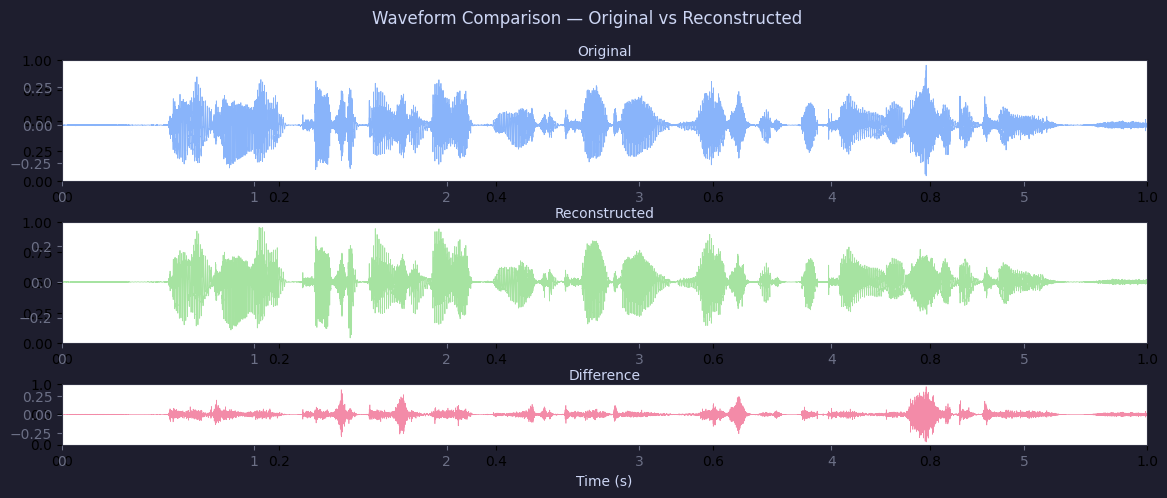

SNR: 7.4 dB


In [23]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

orig_np  = np.array(processed_audio[0, 0, :], dtype=np.float32)
recon_np = np.array(reconstructed[0, 0, :len(orig_np)],   dtype=np.float32)
diff_np  = orig_np - recon_np

t_axis = np.arange(len(orig_np)) / SR

fig = plt.figure(figsize=(14, 5), facecolor='#1e1e2e')
gs  = gridspec.GridSpec(3, 1, height_ratios=[2, 2, 1], hspace=0.4)

for ax in [fig.add_subplot(gs[i]) for i in range(3)]:
    ax.set_facecolor('#1e1e2e')

ax0, ax1, ax2 = [fig.add_subplot(gs[i]) for i in range(3)]

ax0.plot(t_axis, orig_np,  color='#89b4fa', lw=0.6, label='Original')
ax1.plot(t_axis, recon_np, color='#a6e3a1', lw=0.6, label='Reconstructed')
ax2.plot(t_axis, diff_np,  color='#f38ba8', lw=0.5, label='Difference')

for ax, title in zip([ax0, ax1, ax2], ['Original', 'Reconstructed', 'Difference']):
    ax.set_title(title, color='#cdd6f4', fontsize=10, pad=3)
    ax.tick_params(colors='#6c7086')
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')
    ax.set_xlim(0, t_axis[-1])

ax2.set_xlabel('Time (s)', color='#cdd6f4')
fig.suptitle('Waveform Comparison — Original vs Reconstructed', color='#cdd6f4', fontsize=12)
plt.show()

snr = 10 * np.log10(np.mean(orig_np**2) / (np.mean(diff_np**2) + 1e-10))
print(f"SNR: {snr:.1f} dB")


#### 2 — Spectrogram Comparison

Log-power mel-spectrogram side-by-side. This is the standard codec quality check — you can immediately see if high-frequency content is lost, if artefacts appear, or if musical noise is introduced.


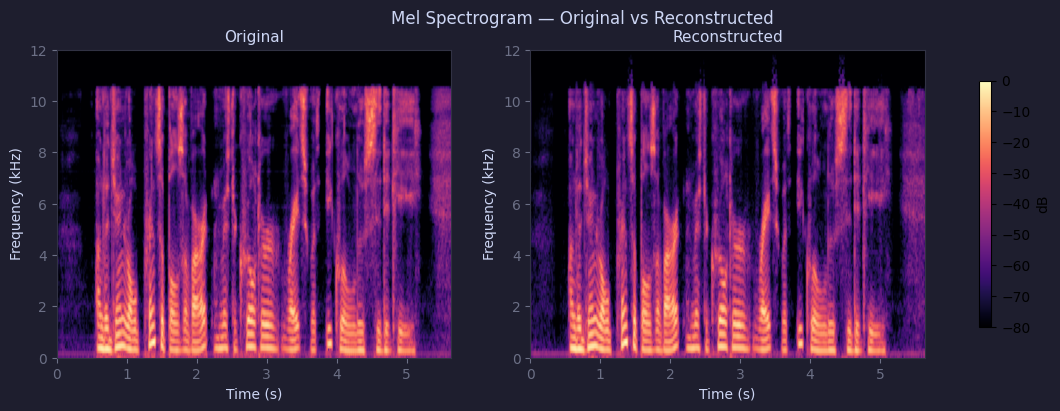

In [20]:
N_MELS, N_FFT, HOP = 128, 1024, 256

def mel_spectrogram(
    signal: np.ndarray,     # [T]
    sr: int = SR,
) -> np.ndarray:            # [n_mels, T_frames]
    S = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
    return librosa.power_to_db(S, ref=np.max)

spec_orig  = mel_spectrogram(orig_np)
spec_recon = mel_spectrogram(recon_np)

vmin = min(spec_orig.min(), spec_recon.min())

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#1e1e2e')
titles = ['Original', 'Reconstructed']
specs  = [spec_orig, spec_recon]

for ax, spec, title in zip(axes, specs, titles):
    ax.set_facecolor('#1e1e2e')
    img = ax.imshow(
        spec, aspect='auto', origin='lower',
        cmap='magma', vmin=vmin, vmax=0,
        extent=[0, len(orig_np) / SR, 0, SR / 2 / 1000]
    )
    ax.set_title(title, color='#cdd6f4', fontsize=11)
    ax.set_xlabel('Time (s)', color='#cdd6f4')
    ax.set_ylabel('Frequency (kHz)', color='#cdd6f4')
    ax.tick_params(colors='#6c7086')
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

fig.colorbar(img, ax=axes, label='dB', shrink=0.8)
fig.suptitle('Mel Spectrogram — Original vs Reconstructed', color='#cdd6f4', fontsize=12)
plt.show()


#### 3 — Discrete Code Heatmap

Each column is one 12.5 Hz time frame; each row is one of the 32 codebooks. The colour is the codebook index (0–2047). This is the "token piano roll" — the exact representation a speech LM like Moshi operates on.


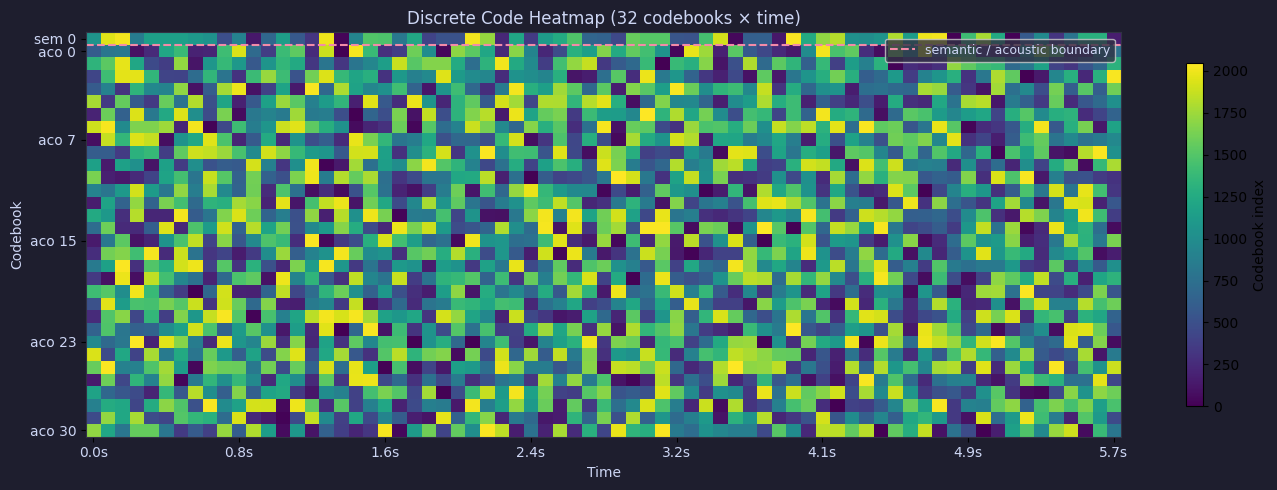

In [21]:
sem = np.array(codes['semantic'][:, 0, :], dtype=np.float32)   # [1, T]
aco = np.array(codes['acoustic'][:, 0, :], dtype=np.float32)   # [31, T]
all_codes = np.concatenate([sem, aco], axis=0)                  # [32, T]

T_frames = all_codes.shape[1]
t_ticks  = np.linspace(0, T_frames / 12.5, num=min(8, T_frames))
t_labels = [f'{v:.1f}s' for v in t_ticks]

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#1e1e2e')
ax.set_facecolor('#1e1e2e')

img = ax.imshow(
    all_codes, aspect='auto', origin='upper',
    cmap='viridis', vmin=0, vmax=2048,
    interpolation='nearest'
)

ax.set_yticks([0, 1, 8, 16, 24, 31])
ax.set_yticklabels(['sem 0', 'aco 0', 'aco 7', 'aco 15', 'aco 23', 'aco 30'], color='#cdd6f4')
ax.set_xticks(np.linspace(0, T_frames - 1, num=min(8, T_frames)))
ax.set_xticklabels(t_labels, color='#cdd6f4')
ax.set_xlabel('Time', color='#cdd6f4')
ax.set_ylabel('Codebook', color='#cdd6f4')
ax.set_title('Discrete Code Heatmap (32 codebooks × time)', color='#cdd6f4', fontsize=12)
ax.axhline(0.5, color='#f38ba8', lw=1.5, linestyle='--', label='semantic / acoustic boundary')
ax.legend(loc='upper right', facecolor='#313244', labelcolor='#cdd6f4', fontsize=9)

for spine in ax.spines.values():
    spine.set_edgecolor('#313244')

fig.colorbar(img, ax=ax, label='Codebook index', shrink=0.85)
plt.tight_layout()
plt.show()


#### 4 — RVQ Residual Energy Decay

Decode with 1 codebook, then 2, then 4, etc., and measure the SNR of the reconstruction at each stage. The curve shows how the acoustic quality budget is allocated across the 32 layers — early layers carry the most information, later ones add fine detail.


k= 1 codebooks → SNR -1.8 dB
k= 2 codebooks → SNR -0.9 dB
k= 4 codebooks → SNR 1.5 dB
k= 8 codebooks → SNR 4.4 dB
k=16 codebooks → SNR 6.3 dB
k=31 codebooks → SNR 7.4 dB


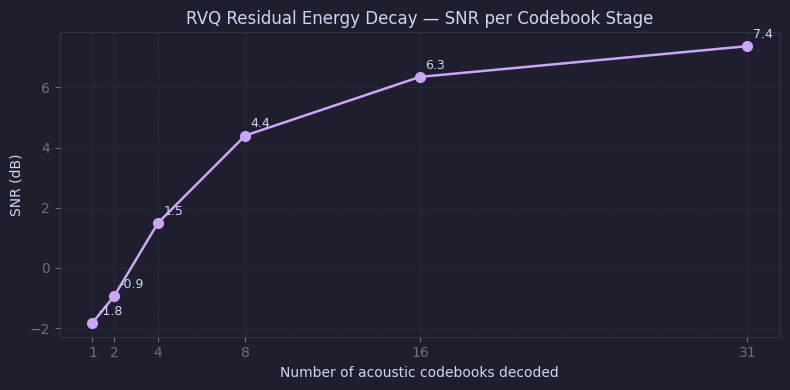

In [22]:
def partial_rvq_decode(
    codes: jax.Array,   # [K, B, T]
    rvq_params: dict,
    n_codebooks: int,
) -> jax.Array:         # [B, T, 512]
    layers        = rvq_params['layers']
    quantized_sum = None
    for i in range(min(n_codebooks, codes.shape[0])):
        cb_matrix     = get_codebook_matrix(layers[str(i)]['codebook'])
        z_q           = cb_matrix[codes[i]]
        quantized_sum = z_q if quantized_sum is None else quantized_sum + z_q
    return quantized_sum @ rvq_params['output_proj']['weight'].squeeze()

def decode_with_k_codebooks(
    codes: dict,
    params: dict,
    k: int,
) -> np.ndarray:        # [T_audio]
    q_params = params['quantizer']
    sem_out  = rvq_decode_from_codes(codes['semantic'], q_params['semantic_residual_vector_quantizer'])
    aco_out  = partial_rvq_decode(codes['acoustic'], q_params['acoustic_residual_vector_quantizer'], n_codebooks=k)
    x        = sem_out + aco_out
    x        = upsample_apply(x, params['upsample'])
    x        = mimi_decoder_transformer_apply(x, params)
    x        = mimi_decoder_apply(x, params)
    return np.array(x[0, :, 0], dtype=np.float32)

checkpoints = [1, 2, 4, 8, 16, 31]
snr_values  = []
sig_power   = np.mean(orig_np ** 2)

for k in checkpoints:
    recon_k   = decode_with_k_codebooks(codes, mimi_weights, k)
    min_len   = min(len(orig_np), len(recon_k))
    diff_k    = orig_np[:min_len] - recon_k[:min_len]
    snr_k     = 10 * np.log10(sig_power / (np.mean(diff_k ** 2) + 1e-10))
    snr_values.append(snr_k)
    print(f"k={k:2d} codebooks → SNR {snr_k:.1f} dB")

fig, ax = plt.subplots(figsize=(8, 4), facecolor='#1e1e2e')
ax.set_facecolor('#1e1e2e')

ax.plot(checkpoints, snr_values, color='#cba6f7', marker='o', lw=1.8, markersize=7)
for x_val, y_val in zip(checkpoints, snr_values):
    ax.annotate(f'{y_val:.1f}', (x_val, y_val), textcoords='offset points',
                xytext=(4, 6), color='#cdd6f4', fontsize=9)

ax.set_xlabel('Number of acoustic codebooks decoded', color='#cdd6f4')
ax.set_ylabel('SNR (dB)', color='#cdd6f4')
ax.set_title('RVQ Residual Energy Decay — SNR per Codebook Stage', color='#cdd6f4', fontsize=12)
ax.tick_params(colors='#6c7086')
ax.set_xticks(checkpoints)
ax.grid(color='#313244', linestyle='--', lw=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()
